# Exercise 2.2, Graph Analysis with Matplotlib
## Teresa Ferrill, September 21, 2025

-----------------------------------------------------------------------------------------------------------------
*1.   Using a data set of your choice, write an introduction explaining the data set.*

I am using the IMDB Top 950 Movies Dataset, downloaded from Kaggle.
This dataset presents detailed metadata for IMDb’s Top Rated films.  Sourced by scraping the IMDb website, it contains 950 entries (rows) and numerous columns detailing aspects of each film, including rating, genre, and key personnel. The data is compiled for non-commercial, educational use and is designed for data analysis, machine learning, and visualization projects related to cinema

-----------------------------------------------------------------------------------------------------------------
*2. Identify a question or question(s) that you would like to explore in your data set.*

1. Who directed the most movies in the dataset, and how many did they direct?
2. What is the range and distribution of the IMDB ratings - is the distribution skewed to the low side or high side, or is the distribution even?
3. What is the relationship between the average Meta Score and IMDb Rating, based on or grouped by the director?

-----------------------------------------------------------------------------------------------------------------
*3. Create at least three graphs that help answer these questions. Make sure your graphs are clearly readable and are labeled appropriately and professionally.*

In [1]:
# Import matplotlib.pyplot for plotting functionalities 
import matplotlib.pyplot as plt

# Import pandas for data handling
import pandas as pd

# Import seaborn to support statistical analysis
import seaborn as sns

# Load Data
df = pd.read_csv('imdb-top-rated-movies-user-rated.csv') 

-----------------------------------------------------------------------------------------------------------------
Starting by investigating the dataset
1. Inspect the first 5 rows
2. Review the dimensions
3. List the columns with datatypes 

In [2]:
# View first 5 rows of data
df.head(5)

,Rank,Title,IMDb Rating,Votes,Poster URL,Video URL,Meta Score,Tags,Director,Description,Writers,Stars,Summary,Worldwide Gross
0,1,Once Upon a Time... in Hollywood,7.6,927K,https://www.imdb.com/title/tt7131622/mediaview...,https://imdb-video.media-imdb.com/vi1385741849...,84.0,"""Period Drama, Showbiz Drama, Comedy, Drama""",Quentin Tarantino,"""As Hollywood's Golden Age is winding down dur...",Quentin Tarantino,"""Leonardo DiCaprio, Brad Pitt, Margot Robbie""","""Reviewers say 'Once Upon a Time in Hollywood'...",-
1,2,Mission: Impossible - Dead Reckoning Part One,7.6,311K,https://www.imdb.com/title/tt9603212/mediaview...,https://imdb-video.media-imdb.com/vi3500918553...,81.0,"""Action Epic, Adventure Epic, Spy, Action, Adv...",Christopher McQuarrie,Ethan Hunt and his IMF team must track down a ...,"""Bruce Geller, Christopher McQuarrie, Erik Jen...","""Tom Cruise, Hayley Atwell, Ving Rhames""","""Reviewers say 'Mission: Impossible - Dead Rec...",-
2,3,John Wick: Chapter 4,7.6,392K,https://www.imdb.com/title/tt10366206/mediavie...,https://imdb-video.media-imdb.com/vi289916185/...,78.0,"""Action Epic, Gun Fu, One,Person Army Action, ...",Chad Stahelski,"""John Wick uncovers a path to defeating The Hi...","""Shay Hatten, Michael Finch, Derek Kolstad""","""Keanu Reeves, Laurence Fishburne, George Geor...","""Reviewers say 'John Wick: Chapter 4' is laude...",-
3,4,Watchmen,7.6,603K,https://www.imdb.com/title/tt0409459/mediaview...,https://imdb-video.media-imdb.com/vi240565017/...,56.0,"""Dystopian Sci,Fi, Superhero, Action, Drama, M...",Zack Snyder,"""In a version of 1985 where superheroes exist-...","""Dave Gibbons, David Hayter, Alex Tse""","""Jackie Earle Haley, Patrick Wilson, Carla Gug...","""Reviewers say 'Watchmen' is acclaimed for its...",-
4,5,The Fifth Element,7.6,533K,https://www.imdb.com/title/tt0119116/mediaview...,https://imdb-video.media-imdb.com/vi854720793/...,52.0,"""Sci,Fi Epic, Space Sci,Fi, Action, Adventure,...",Luc Besson,"""In the colorful future- a cab driver unwittin...","""Luc Besson, Robert Mark Kamen""","""Bruce Willis, Milla Jovovich, Gary Oldman""",-,-


In [3]:
# Dataset number of columns and rows
df.shape

(950, 14)

In [4]:
# Total number of elements in the dataframe
df.size

13300

In [5]:
# Column names with datatype
print('Data types:')
print(df.dtypes)

Data types:
Rank                 int64
Title               object
IMDb Rating        float64
Votes               object
Poster URL          object
Video URL           object
Meta Score         float64
Tags                object
Director            object
Description         object
Writers             object
Stars               object
Summary             object
Worldwide Gross     object
dtype: object


-----------------------------------------------------------------------------------------------------------------
Next, perform data cleaning and review
1. Convert Votes column from string to numeric
2. Convert Worldwide Gross column from string to numeric
3. Review datatype conversion and counts of null values

In [6]:
# Cleaning 'Votes' column
# Remove commas then convert to numeric
df['Votes'] = df['Votes'].str.replace(',', '', regex=True)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Cleaning 'Worldwide Gross' column
# Remove '$' and commas then convert to numeric
df['Worldwide Gross'] = df['Worldwide Gross'].str.replace('[\$,]', '', regex=True)
df['Worldwide Gross'] = pd.to_numeric(df['Worldwide Gross'], errors='coerce')

# Review datatype conversion - Votes and Worldwide Gross columns should be numeric fields
# Review dataset - List Column Name, Datatype, and Number of NaN rows

# Print header
print(f"{'Column Name':<20} {'Data Type':<15} {'NaN Count':<10}")
print("-" * 45)

# Iterate through columns and print column information
for col in df.columns:
    # Capture the column name
    col_name = col
    # Capture the Datatype
    data_type = str(df[col].dtype)
    # Count number of rows with NaN values
    nan_count = df[col].isnull().sum()
    # Print the results
    print(f"{col_name:<20} {data_type:<15} {nan_count:<10}")

Column Name          Data Type       NaN Count 
---------------------------------------------
Rank                 int64           0         
Title                object          0         
IMDb Rating          float64         0         
Votes                float64         950       
Poster URL           object          0         
Video URL            object          32        
Meta Score           float64         157       
Tags                 object          0         
Director             object          0         
Description          object          0         
Writers              object          0         
Stars                object          1         
Summary              object          652       
Worldwide Gross      float64         950       


Observations of the dataset
1. There are 950 rows in the dataset
2. All rows of the dataset have NaN values for Votes and Worldwide Gross - cannot do analysis using these columns
3. All rows have values for IMDb Rating and Director
4. All but 157 rows have values for Meta Score

-----------------------------------------------------------------------------------------------------------------
Question number 1:
Who directed the most movies in the dataset, and how many did they direct?

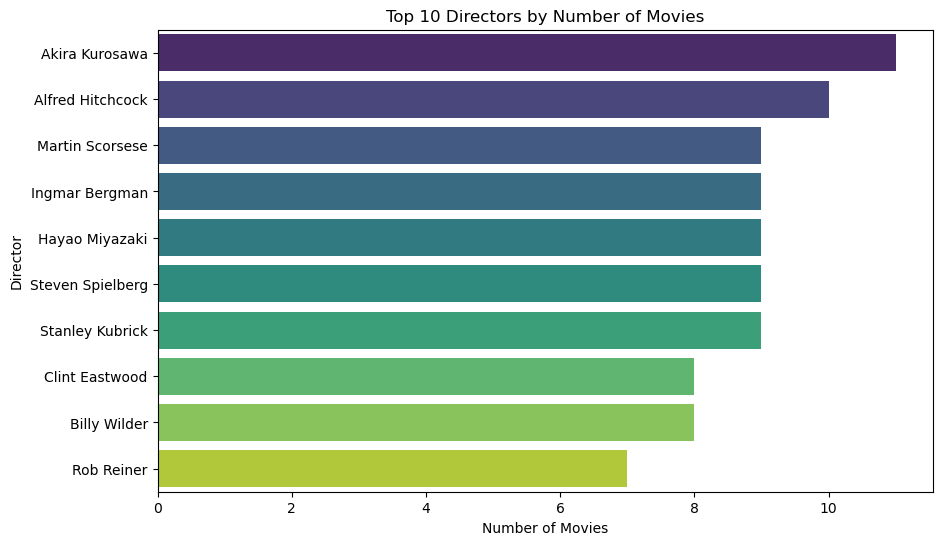

In [7]:
# Count or Bar plot for top 10 Directors

# Set the plot size to 10 inches wide and 6 inches tall
plt.figure(figsize=(10, 6))

# Using the Director column, count how many times that director appears, then select the top 10 
top_directors = df['Director'].value_counts().nlargest(10)

# Select the Bar Plot (sns.barplot)
# Each Director is treated as a separate hue group within the plot (hue=top_directors.index)
# There is only one bar per director (dodge=false)
# The Legend is turned off since the y-axis label already exists as the director’s name (legend=False)
# Assigned the Viridis colormap as the palette, a uniform gradient from dark purple to yellow, across the directors bars (palette="viridis")
sns.barplot(x=top_directors.values,y=top_directors.index,hue=top_directors.index,dodge=False,legend=False,palette="viridis")

# Add a title to the plot
plt.title('Top 10 Directors by Number of Movies')

# Add x and y axis labels
plt.xlabel('Number of Movies')
plt.ylabel('Director')

# Draw the plot
plt.show()

Answer: Akira Kurosawa directed the most number of movies in the dataset with 11 movies.

-----------------------------------------------------------------------------------------------------------------
Question 2: What is the range and distribution of the IMDB ratings - is the distribution skewed to the low side or high side, or is the distribution even?

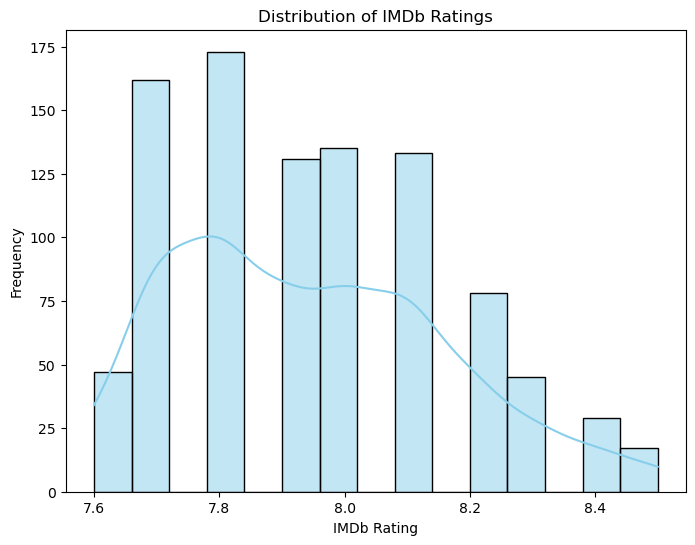

Ratings range from 7.6 to 8.5 with an average rating of 7.94


In [8]:
# Histogram Plot for IMDb Rating

# Find the minimum rating score
min_rating = df['IMDb Rating'].min()

# Find the maximum rating score
max_rating = df['IMDb Rating'].max()

# Find the average rating score  round(number, 2)
avg_rating=round(df['IMDb Rating'].mean(),2)

# Set the plot size to 8 inches wide and 6 inches tall
plt.figure(figsize=(8, 6))

# Select a Histogram Plot (sns.histplot)
# Select the IMDb Rating column to show how many movies fall into each rating interval (df['IMDb Rating'])
# Add a Kernel Density Estimate (KDE) to place a curve line on top of the histogram that estimates the probability distribution of ratings (kde-True)
# Set the color of the histogram bars to sky blue, also sets the line to a similar color (color='skyblue')
sns.histplot(df['IMDb Rating'], kde=True, color='skyblue')

# Add a title to the plot
plt.title('Distribution of IMDb Ratings')

# Add x and y axis labels
plt.xlabel('IMDb Rating')
plt.ylabel('Frequency')

# Draw the plot
plt.show()

# Print the minimum, maximum, and average IMDb Ratings
print('Ratings range from', min_rating, 'to', max_rating,'with an average rating of',avg_rating)

Answer: The ratings range from 7.6 to 8.5.  The distribution of the ratings is skewed - there are more ratings closer to 7.6 than to 8.5, with the majority of ratings just above 7.8.

-----------------------------------------------------------------------------------------------------------------
Question 3: What is the relationship between the average Meta Score and IMDb Rating, based on or grouped by the director?

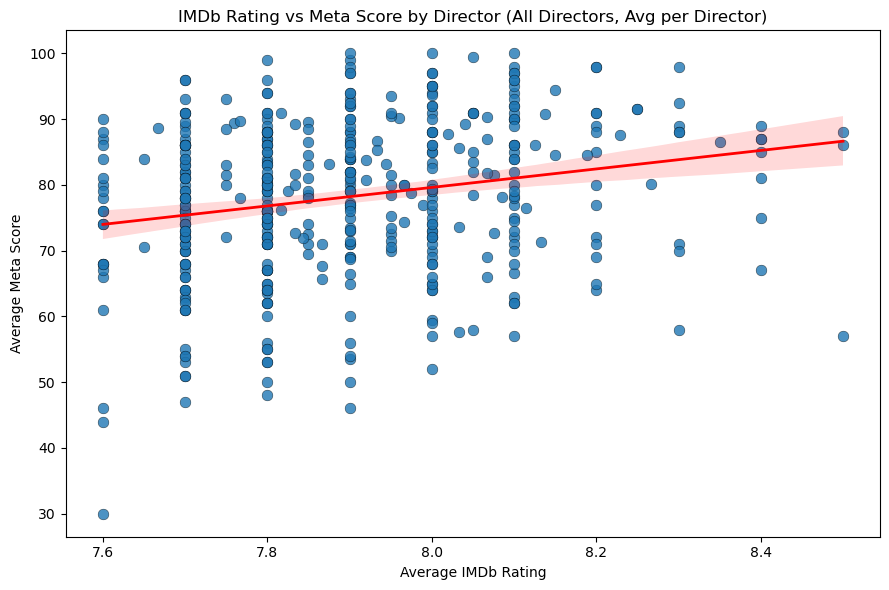

In [9]:
# Scatter Plot for IMDb Rating vs Meta Score by Director

# Clean dataset - remove the Meta Score NaN rows
df_clean = df.dropna(subset=["Meta Score"])

# Collect the statistics on each Director based on their IMDb Rating (public opinion) and Meta Score (critic opinion)
director_stats = (df_clean.groupby("Director")[["IMDb Rating","Meta Score"]].mean().reset_index().dropna(subset=["IMDb Rating", "Meta Score"]))

# Set the plot size to 9 inches wide and 6 inches tall
plt.figure(figsize=(9,6))

# Select a Scatter Plot (sns.scatterplot)
# Use the director_stats dataset (data=director_stats)
# Set the x-axis to IMDb Rating (x="IMDb Rating")
# Set the y-axis to Meta Score (y="Meta Score")
# Set the color of the histogram bars to sky blue, also sets the line to a similar color (color='skyblue')
# Set the size of the markers in the plot (s=60)
# Set the transparency of the markers (alpha=0.8 - 80%)
# Set the color of the line around each marker (edgecolor="black")
# Set the thickness of the marker's edge (linewidth=0.3)
sns.scatterplot(data=director_stats,x="IMDb Rating",y="Meta Score", s=60, alpha=0.8, edgecolor="black", linewidth=0.3)

# Create Regression Plot (sns.regplot)
# Use the director_stats dataset (data=director_stats)
# Set the x-axis to IMDb Rating (x="IMDb Rating")
# Set the y-axis to Meta Score (y="Meta Score")
# Instruct regplot() not to display the individual data points (scatter plot) on the graph (scatter=False)
# Pass color, size, edgecolor variables to matplotlib.pyplog.scatter (these parameters will have no visible effect on the plot as scatter is set to False
# Set the parameters for the regression line to red with a linewidth of 2 (link_kws={"color": "red", "linewidth": 2})
sns.regplot(data=director_stats, x="IMDb Rating", y="Meta Score", scatter=False, scatter_kws={"color": "skyblue", "s": 60, "edgecolor": "black"}, line_kws={"color": "red", "linewidth": 2})

# Add a title to the plot
plt.title("IMDb Rating vs Meta Score by Director (All Directors, Avg per Director)")

# Add x and y axis labels
plt.xlabel("Average IMDb Rating")
plt.ylabel("Average Meta Score")

# Adjust subplot parameters to ensure all elements within the figure fit (plt.tight_layout())
plt.tight_layout()

# Draw the plot
plt.show()

Answer: The IMDb Rating and Meta Score are positively associated.  In general, when the IMDb Rating goes up, the Meta Score goes up too.  The ratings and scores are most closely related near the center of the plot, where the dots are clustered closely towards the center of the line.

-----------------------------------------------------------------------------------------------------------------
4. Explain what you have learned from each of your graphs.  

- Bar Plot - A bar plot is best for comparing values across discrete categories in a way that is immediately visible and easy to interpret.  By presenting a magnitude of values, Bar plots make it straightforward to see not just rank order, but also how much bigger or smaller one category is compared to another.  
__With the Bar Plot, I was able to determine the top 10 directors contained in the dataset.  I found that the top number of movies for the top director was only 11 out of the 950 in the dataset.  I was surprised at how many of the names on the list I knew.  With a little more research, I found it interesting that of the top 10, only 5 directors have directed a movie in the last decade, 4 directors' last movie was before the year 2000, and the number 2 director's last movie was made in 1976 - Alfred Hitchcock.  

- Histogram Plot w/KDE - A Histogram with a Kernel Density Estimate (KDE) combines raw counts with a smooth estimate of the underlying probability        distribution. This pairing helps one interpret the true shape of their data more reliably.  The histogram shows how often data falls into each bin,        and the KDE reveals where the data naturally clusters, making it easier to see if data leans left or right compared to just looking at bars.  
__With the Histogram Plot, I found that while the average rating was just below 8, which is almost the middle of the range of the ratings (7.6 to 8.5), the majority of movie ratings fell between 7.7 and 7.8.  This tells me that the ratings are both consistently high and tightly clustered.

- Scatter Plot w/regression line - A scatter plot with a regression line is a clear way to explore relationships between two variables and shows the        relationship, strength, and direction between the variables, while also providing a predictive model that can be visually interpreted.  This type of        plot provides practical insights - the scatter plot dots show the raw story of individual cases, while the regression line shows the general rule.        Together, they provide data-driven insights and predictions in practical contexts.  
__The Scatter Plot shows a positive relationship between the IMDb Ratings and Meta Scores for the directors.  As the IMDb Rating increases, so does the Meta Score. Most of the data clusters near the middle of the regression line - this is where the relationship is strong and consistent. At the extreme low and high ends, the relationship is more scattered, meaning outcomes are less predictable there.


-----------------------------------------------------------------------------------------------------------------
5. Write a conclusion that summarizes your findings.

With the highest number of films by any one director at 11 out of 950, there has to be a great number of directors in the dataset.  This is an indicator to me that there are many genres of movies, which means this set of movies would appeal to a wide range of audiences.  

The IMDb Rating reflects the audience's opinion of the movie, which can be prone to popularity bias.  With such a small range between the highest and lowest rating within the whole of the dataset, I am led to believe these movies would be considered 'worth seeing' or 'worth seeing again' by most audiences.

The Meta Score is an indicator of critical reception and quality.  When considering a specific director, audience opinion and critical reception are in parallel - if the movie is positively received by the public, it is positively reviewed by the critics.  This is indicated by the upward regression line in the scatter plot.  It is important to note that while the overall trend is positive, individual directors or films may deviate from that pattern.

In summary, these findings would indicate that, overall, the directors and their movies in this dataset would be labeled 'the best of the best' by most audiences and critics alike. 
